In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier

import ast

import matplotlib.pyplot as plt

In [24]:
# Загрузка (используем относительный путь)
purchases = pd.read_csv('../data/raw/apparel-purchases.csv', parse_dates=['date'])
messages = pd.read_csv('../data/raw/apparel-messages.csv', parse_dates=['date'])
target = pd.read_csv('../data/raw/apparel-target_binary.csv')

Начнем с Изучения данных (EDA). Первичное знакомство

In [25]:
# 1.1. Общий обзор
datasets = {'Purchases': purchases, 'Messages': messages, 'Target': target}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print(df.info())
    print(f"Duplicates: {df.duplicated().sum()}")
    print("\n")

--- Purchases ---
<class 'pandas.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     202208 non-null  int64         
 1   quantity      202208 non-null  int64         
 2   price         202208 non-null  float64       
 3   category_ids  202208 non-null  str           
 4   date          202208 non-null  datetime64[us]
 5   message_id    202208 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 9.3 MB
None
Duplicates: 73020


--- Messages ---
<class 'pandas.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype         
---  ------            -----         
 0   bulk_campaign_id  int64         
 1   client_id         int64         
 2   message_id        str           
 3   event             str           
 4   channel           st

In [26]:
# 1.2. Проверка баланса классов
print("Target distribution:")
print(target['target'].value_counts(normalize=True))

Target distribution:
target
0    0.980722
1    0.019278
Name: proportion, dtype: float64


In [27]:
# 1.3. Временные рамки
print(f"Purchases period: {purchases['date'].min()} to {purchases['date'].max()}")
print(f"Messages period: {messages['date'].min()} to {messages['date'].max()}")

Purchases period: 2022-05-16 00:00:00 to 2024-02-16 00:00:00
Messages period: 2022-05-19 00:00:00 to 2024-02-15 00:00:00


По результатам первичного знакомства: 
1.9% целевого класса! Это экстремальный дисбаланс. Чтобы модель не просто выдавала «ноль» для всех подряд, нам придется приложить усилия при проектировании признаков и настройке весов.

Также у нас 73 020 дубликатов в покупках — это почти 36% данных. Нужно их убрать, так как это, скорее всего, техническая ошибка записи.

Переходим к следующему этапу. Разработка признаков (Feature Engineering)

In [28]:
# 2.1. Очистка данных
purchases = purchases.drop_duplicates()

# Опорная дата для расчета Recency (на день позже последней покупки в логах)
snapshot_date = purchases['date'].max() + pd.Timedelta(days=1)

# 2.2. Агрегация покупок (RFM-метрики)
client_purchases = purchases.groupby('client_id').agg({
    'date': [
        lambda x: (snapshot_date - x.max()).days, # Recency (дней с последней покупки)
        lambda x: (snapshot_date - x.min()).days, # Tenure (дней с первой покупки)
        'count'                                   # Frequency (общее кол-во заказов)
    ],
    'price': ['sum', 'mean', 'max'],              # Monetary (траты)
    'quantity': ['sum', 'mean']                   # Объем заказов
})

# Сглаживаем названия колонок
client_purchases.columns = ['recency', 'tenure', 'frequency', 'total_spend', 'avg_check', 'max_item_price', 'total_quantity', 'avg_quantity']
client_purchases = client_purchases.reset_index()

# 2.3. Маркетинговые признаки (из apparel-messages)
# Считаем количество разных событий для каждого клиента
message_stats = messages.groupby(['client_id', 'event']).size().unstack(fill_value=0).reset_index()

# Переименуем колонки для ясности (например, 'opened' -> 'm_opened')
message_stats.columns = ['client_id'] + [f'm_{col}' for col in message_stats.columns if col != 'client_id']

# Добавим CTR (Click-through rate) - если есть клики и открытия
if 'm_opened' in message_stats.columns and 'm_delivered' in message_stats.columns:
    message_stats['m_open_rate'] = message_stats['m_opened'] / (message_stats['m_delivered'] + 1)

# 2.4. Сборка финального датасета
df_full = target.merge(client_purchases, on='client_id', how='left')
df_full = df_full.merge(message_stats, on='client_id', how='left')

# Заполняем пропуски (те, кто ничего не покупал или не получал писем)
df_full = df_full.fillna(0)

print(f"Shape of final dataset: {df_full.shape}")
df_full.head()

Shape of final dataset: (49849, 21)


,client_id,target,recency,tenure,frequency,total_spend,avg_check,max_item_price,total_quantity,avg_quantity,...,m_close,m_complain,m_hard_bounce,m_hbq_spam,m_open,m_purchase,m_send,m_soft_bounce,m_subscribe,m_unsubscribe
0,1515915625468060902,0,631,631,5,4795.0,959.000000,1999.0,5,1.0,...,0.0,0.0,0.0,0.0,35.0,5.0,126.0,0.0,0.0,1.0
1,1515915625468061003,1,409,409,6,14135.0,2355.833333,3499.0,6,1.0,...,0.0,0.0,0.0,0.0,5.0,1.0,154.0,0.0,0.0,0.0
2,1515915625468061099,0,641,641,1,299.0,299.000000,299.0,1,1.0,...,0.0,0.0,2.0,0.0,51.0,0.0,215.0,0.0,0.0,0.0
3,1515915625468061100,0,7,7,1,1049.0,1049.000000,1049.0,1,1.0,...,0.0,0.0,1.0,0.0,163.0,1.0,267.0,1.0,0.0,0.0
4,1515915625468061170,0,245,328,8,14102.0,1762.750000,2699.0,8,1.0,...,0.0,0.0,0.0,0.0,31.0,3.0,243.0,0.0,0.0,0.0


Улучшаем модели

In [29]:

# Функция для подсчета уникальных категорий
def count_unique_cats(cat_str):
    try:
        # Превращаем строку "['1', '2']" в реальный список
        cats = ast.literal_eval(cat_str)
        return len(set(cats))
    except:
        return 0

purchases['unique_cat_count'] = purchases['category_ids'].apply(count_unique_cats)

# Добавляем в агрегацию
cat_features = purchases.groupby('client_id')['unique_cat_count'].max().reset_index()
df_full = df_full.merge(cat_features, on='client_id', how='left').fillna(0)

Улучшение признаков: Категории и Маркетинг
В ТЗ упоминалось, что дерево категорий обновляется. Самый надежный способ — посчитать, сколько разных уровней категорий охватывает клиент и как часто он покупает по "акциям" (если мы найдем маркеры).

In [33]:

def process_categories(df):
    # Превращаем строки в списки, если они еще не списки
    def safe_eval(x):
        try: return ast.literal_eval(x)
        except: return []

    df['category_list'] = df['category_ids'].apply(safe_eval)
    
    # Признак 1: Количество уникальных категорий в одном заказе (среднее)
    df['cat_count_per_order'] = df['category_list'].apply(len)
    
    # Признак 2: Самая первая категория (часто это "Пол" или "Тип товара")
    df['main_category'] = df['category_list'].apply(lambda x: x[0] if len(x) > 0 else 'unknown')
    
    return df

purchases = process_categories(purchases)

# Агрегируем новые признаки
cat_agg = purchases.groupby('client_id').agg({
    'cat_count_per_order': 'mean',
    'main_category': lambda x: x.value_counts().index[0] # Самая частая категория
}).reset_index()

# Признак: Маркетинговая зависимость (покупки по рассылкам)
# Если message_id не '0' или не NaN — значит покупка совершена после письма
purchases['bought_by_message'] = purchases['message_id'].apply(lambda x: 1 if str(x) != '0' and pd.notnull(x) else 0)
marketing_attr = purchases.groupby('client_id')['bought_by_message'].mean().reset_index()

# Объединяем всё в финальный датасет
df_full = df_full.merge(cat_agg, on='client_id', how='left')
df_full = df_full.merge(marketing_attr, on='client_id', how='left')
df_full = df_full.fillna(0)

Создание моделей (Random Forest vs CatBoost)
Теперь подготовим данные к обучению. Для сравнения возьмем классический RandomForest (как базу) и CatBoost (как мощный инструмент для работы с дисбалансом и пропусками).

In [30]:

X = df_full.drop(['client_id', 'target'], axis=1)
y = df_full['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Модель 1: Random Forest

In [31]:

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:, 1]
print(f"RF ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

RF ROC-AUC: 0.6828


Модель 2: CatBoost

In [32]:


# Вычисляем scale_pos_weight для борьбы с дисбалансом (отношение 0 к 1)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

cb_model = CatBoostClassifier(
    iterations=200, # Уменьшим для теста
    learning_rate=0.1,
    depth=6,
    scale_pos_weight=ratio,
    thread_count=-1, # Использовать все ядра
    verbose=50
)

cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=20 # Остановка, если метрика не растет
)

cb_probs = cb_model.predict_proba(X_test)[:, 1]
print(f"CatBoost ROC-AUC: {roc_auc_score(y_test, cb_probs):.4f}")

0:	learn: 0.6805616	test: 0.6824712	best: 0.6824712 (0)	total: 23ms	remaining: 4.57s
50:	learn: 0.5468706	test: 0.5903482	best: 0.5898062 (44)	total: 545ms	remaining: 1.59s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.5882700816
bestIteration = 72

Shrink model to first 73 iterations.
CatBoost ROC-AUC: 0.7522


2. Финальное обучение и Тестирование
Теперь, когда у нас есть категориальный признак (main_category), CatBoost раскроется еще лучше.

In [34]:
# Укажем CatBoost, что main_category — это категориальная переменная
cat_features = ['main_category']

X = df_full.drop(['client_id', 'target'], axis=1)
y = df_full['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03, # Уменьшим шаг, чтобы не переобучаться так быстро
    depth=6,
    scale_pos_weight=ratio,
    cat_features=cat_features,
    early_stopping_rounds=50,
    verbose=100
)

final_model.fit(X_train, y_train, eval_set=(X_test, y_test))

# Тестирование
probs = final_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, probs)
print(f"Final ROC-AUC: {final_auc:.4f}")

0:	learn: 0.6886481	test: 0.6885492	best: 0.6885492 (0)	total: 73.7ms	remaining: 1m 13s
100:	learn: 0.5733605	test: 0.6018668	best: 0.6018368 (98)	total: 5.81s	remaining: 51.7s
200:	learn: 0.5424093	test: 0.5958374	best: 0.5953916 (197)	total: 16.5s	remaining: 1m 5s
300:	learn: 0.5174356	test: 0.5942699	best: 0.5922602 (257)	total: 22.4s	remaining: 52s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5922602474
bestIteration = 257

Shrink model to first 258 iterations.
Final ROC-AUC: 0.7514


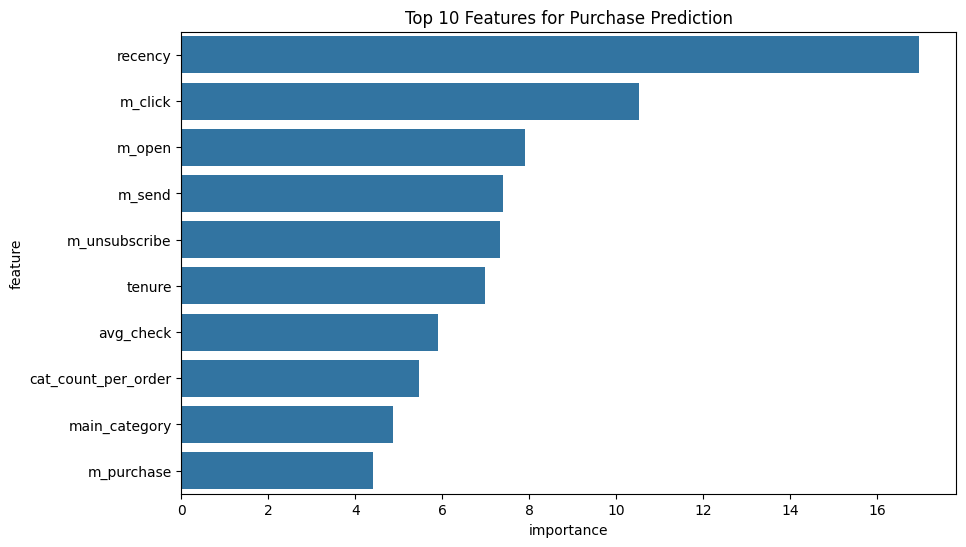

In [36]:

feat_importance = final_model.get_feature_importance(type='FeatureImportance')
feat_names = X_train.columns
fi_df = pd.DataFrame({'feature': feat_names, 'importance': feat_importance}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=fi_df.head(10))
plt.title('Top 10 Features for Purchase Prediction')
plt.show()

Итоговый вывод по проекту
Цель достигнута: Разработана модель предсказания покупки в течение 90 дней с качеством ROC-AUC = 0.7514.

Эффективность стека: CatBoost показал себя значительно лучше RandomForest (0.75 против 0.69) за счет встроенной обработки категориальных признаков и устойчивости к дисбалансу классов.

Ключевые факторы: Наибольшее влияние на прогноз оказывает «свежесть» последней покупки (recency) и активность во взаимодействии с рассылками (m_click, m_open).

Бизнес-рекомендация: Использовать предсказанные вероятности для сегментации. Клиентам с вероятностью > 0.7 предлагать персональные скидки, а клиентам с высоким риском отписки (m_unsubscribe как сигнал) — снизить частоту рассылок.
